# Transfer learning across structures — LANL → cantilever

Demonstrates that a damage-detection model trained on the **Los Alamos
3-storey building** can be reused as the initialisation for the
**cantilever beam** detection model, even though the two structures share
nothing beyond "linear vibrations measured as FRFs".

The story uses pymodal's collection-owns-its-model feature: each
`pymodal.frf` collection holds, alongside its HDF5-backed FRFs, the path
of one or more attached PyTorch state dicts (`coll.save_model(...)`,
`coll.load_model(...)`). The transfer-learning step is then literally:

```python
lanl_coll.save_model(detection_cnn, role='detection')
...
cantilever_init = lanl_coll.load_model(DetectionCNN, role='detection',
                                         n_channels=lanl_channels)
```

The **only architectural difference** between the two detection heads is
the input layer: LANL has 16 sensors × 2 features = 32 channels, the
cantilever has 10 × 2 = 20. This notebook copies every shape-compatible
weight from the LANL state dict into a fresh cantilever network and
fine-tunes the rest, then compares the result to a from-scratch
baseline.

| section | what it does |
|---|---|
| 1 | build small LANL + cantilever datasets in-process (30 samples / class) and persist each via `pymodal.frf` |
| 2 | define `DetectionCNN(n_channels)` - the architecture shared between source and target |
| 3 | train the source detection head on LANL, save it on the LANL collection |
| 4 | baseline: train a *from-scratch* cantilever detection head |
| 5 | transfer: build a fresh cantilever head, copy every shape-matching weight from the LANL state dict, fine-tune |
| 6 | compare loss curves and final test accuracies |

The whole notebook is self-contained: it does not require the LANL or
cantilever notebooks to have been run beforehand.


## Setup


In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

HERE = Path(os.getcwd()).resolve()
EXAMPLE_DIR = HERE / "examples" / "transfer_learning" if (HERE / "examples").exists() else HERE
REPO_ROOT = EXAMPLE_DIR.parent.parent
LANL_DIR = REPO_ROOT / "examples" / "los_alamos_3story"
CAN_DIR  = REPO_ROOT / "examples" / "cantilever_crack"
# pymodal itself comes from REPO_ROOT; the example dirs are only added one at
# a time around their imports, so identical module names across examples
# (params.py, damage_scenarios.py) do not collide.
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pymodal
print("pymodal", pymodal.__version__,
      "  LANL example dir :", LANL_DIR.exists(),
      "  cantilever example dir:", CAN_DIR.exists())


def _swap_to_example(example_dir, module_names=("params", "damage_scenarios",
                                                  "reduced_model", "cantilever_model")):
    '''Make ``example_dir`` the front of ``sys.path`` and flush previously
    imported module objects of the same name so that subsequent imports
    pull from this directory.'''
    other_dirs = [LANL_DIR, CAN_DIR]
    for d in other_dirs:
        d_str = str(d)
        if d_str in sys.path:
            sys.path.remove(d_str)
    sys.path.insert(0, str(example_dir))
    for m in module_names:
        sys.modules.pop(m, None)


pymodal 0.2.0   LANL example dir : True   cantilever example dir: True


## 1. Build small LANL + cantilever datasets

We re-use the existing `damage_scenarios` modules from each example. To
keep the demo runtime under control we build small versions of each.

For the cantilever we deliberately restrict the damage grid to **three
positions × two depths** (six cracked classes, pristine excluded), all
positioned and sized so they shift at least one mode by a clearly
measurable amount. The full cantilever demo uses a six-by-four grid that
includes near-invisible tip cracks (a 0.10 × h crack at 0.85 × L barely
moves any mode) and is harder to learn at this small dataset size.


In [2]:
# --- LANL ---
_swap_to_example(LANL_DIR)
import damage_scenarios as LANL_DS               # examples/los_alamos_3story/damage_scenarios.py
import params as LANL_P
import reduced_model as LANL_RM
lanl_scenarios = LANL_DS.los_alamos_scenarios()
lanl_inputs    = LANL_DS.shaker_input()
lanl_outputs   = LANL_DS.column_intersection_outputs()
lanl_freqs     = np.arange(1.0, 200.5, 0.5)
lanl_h5 = EXAMPLE_DIR / "lanl_small.h5"
if lanl_h5.exists():
    lanl_h5.unlink()
t0 = time.time()
lanl_coll = LANL_DS.build_dataset(
    lanl_scenarios, n_per_scenario=30,
    inputs=lanl_inputs, outputs=lanl_outputs,
    freq_array=lanl_freqs, path=lanl_h5, seed=0,
)
print(f"LANL: {len(lanl_coll)} items, item shape {lanl_coll.measurements[0].shape}, "
      f"built in {time.time()-t0:.1f}s")
lanl_is_dmg, *_ = LANL_DS.scenario_meta(lanl_scenarios)
lanl_n_channels = 2 * len(lanl_outputs) * len(lanl_inputs)        # mag + phase

# --- cantilever (swap sys.path / sys.modules first so re-imports resolve here) ---
_swap_to_example(CAN_DIR)
import params as CAN_P
import damage_scenarios as CAN_DS
import cantilever_model as CAN_CM
# Restricted damage grid - drops the near-invisible tip cracks
CAN_POSITIONS = (0.20, 0.40, 0.60)
CAN_DEPTHS    = (0.30, 0.50)
can_scenarios = CAN_DS.cantilever_scenarios(positions=CAN_POSITIONS, depths=CAN_DEPTHS)
can_inputs    = CAN_DS.shaker_input()
can_outputs   = CAN_DS.sensor_outputs()
can_freqs     = np.arange(CAN_P.F_MIN, CAN_P.F_MAX + CAN_P.F_STEP/2, CAN_P.F_STEP)
can_h5 = EXAMPLE_DIR / "cantilever_small.h5"
if can_h5.exists():
    can_h5.unlink()
t0 = time.time()
can_coll = CAN_DS.build_dataset(
    can_scenarios, n_per_scenario=60,
    inputs=can_inputs, outputs=can_outputs,
    freq_array=can_freqs, path=can_h5, seed=0,
)
print(f"cantilever: {len(can_coll)} items, item shape {can_coll.measurements[0].shape}, "
      f"built in {time.time()-t0:.1f}s")
can_is_dmg, *_ = CAN_DS.scenario_meta(can_scenarios,
                                         positions=CAN_POSITIONS, depths=CAN_DEPTHS)
can_n_channels = 2 * len(can_outputs) * len(can_inputs)


LANL: 1470 items, item shape (399, 32, 1), built in 6.3s


cantilever: 420 items, item shape (1399, 10, 1), built in 6.9s


## 2. Shared architecture

`DetectionCNN(n_channels)` is the architecture for both source and target
detection heads. It is parameterised only by the input channel count so
the **input conv** has different weights between the two structures
(LANL: 32 → 32, cantilever: 20 → 32) but every layer afterwards is
**shape-compatible** and can be transferred verbatim.


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class DetectionCNN(nn.Module):
    '''Same architecture for any structure; only the input conv depends
    on ``n_channels``. Layers after the input conv are shape-identical
    across structures, which is what makes transfer learning trivial.'''
    def __init__(self, n_channels: int):
        super().__init__()
        self.input_conv = nn.Conv1d(n_channels, 32, kernel_size=7, padding=3)
        self.backbone = nn.Sequential(
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.backbone(self.input_conv(x))


def to_features(arr):
    '''Globally normalised log-magnitude + unwrapped phase per channel.'''
    z = np.asarray(arr).reshape(arr.shape[0], -1).T
    mag = np.log1p(np.abs(z))
    mag = (mag - mag.mean()) / (mag.std() + 1e-12)
    ph  = np.unwrap(np.angle(z), axis=1)
    ph  = ph / (np.abs(ph).max() + 1e-12)
    return torch.from_numpy(np.concatenate([mag, ph], axis=0).astype(np.float32))


def make_loaders(coll, is_dmg_per_scenario, batch=64, balance=True, seed=0):
    coll.split(0.70, 0.15, 0.15, seed=seed)
    n = len(coll)
    sample_label = np.array([int(coll.labels[i][()]) for i in range(n)])
    binary_label = is_dmg_per_scenario[sample_label].astype(int)
    coll.torch_dataset()
    coll.dataset.transform = to_features

    class HD(torch.utils.data.Dataset):
        def __init__(self, ix, lbl):
            self.ix = list(ix); self.lbl = lbl
        def __len__(self): return len(self.ix)
        def __getitem__(self, i):
            gi = self.ix[i]; x, _ = coll.dataset[gi]
            return x, torch.tensor(int(self.lbl[gi]), dtype=torch.long)

    tr = list(coll.train_indices)
    va = list(coll.val_indices)
    te = list(coll.test_indices)
    if balance:
        tr_lbl = np.asarray([binary_label[i] for i in tr])
        cnt = np.bincount(tr_lbl, minlength=2).astype(float)
        cnt = np.maximum(cnt, 1.0)
        sample_w = 1.0 / cnt[tr_lbl]
        sampler = WeightedRandomSampler(weights=sample_w,
                                          num_samples=len(tr), replacement=True)
        train_loader = DataLoader(HD(tr, binary_label), batch_size=batch, sampler=sampler)
    else:
        train_loader = DataLoader(HD(tr, binary_label), batch_size=batch, shuffle=True)
    val_loader   = DataLoader(HD(va, binary_label), batch_size=128)
    test_loader  = DataLoader(HD(te, binary_label), batch_size=128)
    return train_loader, val_loader, test_loader


def fit(model, train_loader, val_loader, n_epochs, lr, label):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    loss_fn = nn.CrossEntropyLoss()
    history = []
    for ep in range(1, n_epochs + 1):
        model.train(True); cor, tot, ls = 0, 0, 0.0
        for x, y in train_loader:
            x = x.to(device); y = y.to(device)
            opt.zero_grad()
            out = model(x); loss = loss_fn(out, y)
            loss.backward(); opt.step()
            cor += (out.argmax(1) == y).sum().item(); tot += x.size(0)
            ls += loss.item() * x.size(0)
        tr_acc = cor / tot
        model.train(False); cor2, tot2, ls2 = 0, 0, 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device); y = y.to(device)
                out = model(x); loss = loss_fn(out, y)
                cor2 += (out.argmax(1) == y).sum().item(); tot2 += x.size(0)
                ls2 += loss.item() * x.size(0)
        sched.step()
        va_acc = cor2 / tot2
        history.append((ls / tot, tr_acc, ls2 / tot2, va_acc))
        if ep == 1 or ep % 5 == 0 or ep == n_epochs:
            print(f"  [{label}] ep {ep:>3d}  tr loss {ls/tot:.3f} acc {tr_acc:.2%}   "
                  f"val loss {ls2/tot2:.3f} acc {va_acc:.2%}")
    return np.array(history)


def evaluate(model, test_loader):
    ys, yps = [], []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            ys.append(y.numpy())
            yps.append(model(x.to(device)).argmax(1).cpu().numpy())
    ys = np.concatenate(ys); yps = np.concatenate(yps)
    return ys, yps, (ys == yps).mean()


## 3. Train the source detection head on LANL


In [4]:
print("LANL — training detection head from scratch")
lanl_train, lanl_val, lanl_test = make_loaders(lanl_coll, lanl_is_dmg, balance=True)
lanl_model = DetectionCNN(n_channels=lanl_n_channels)
lanl_hist  = fit(lanl_model, lanl_train, lanl_val, n_epochs=20, lr=2e-3, label='LANL')
ys, yps, lanl_test_acc = evaluate(lanl_model, lanl_test)
print(f"LANL detection — test accuracy {lanl_test_acc:.2%}")

# Persist the trained model on the LANL collection
lanl_pt = lanl_coll.save_model(lanl_model, role='detection')
print(f"LANL detection saved to {lanl_pt}")
print(f"attached roles on LANL: {lanl_coll.attached_roles()}")


LANL — training detection head from scratch


  [LANL] ep   1  tr loss 0.425 acc 78.04%   val loss 0.079 acc 96.43%


  [LANL] ep   5  tr loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


  [LANL] ep  10  tr loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


  [LANL] ep  15  tr loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


  [LANL] ep  20  tr loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


LANL detection — test accuracy 100.00%


LANL detection saved to /home/user/pymodal/examples/transfer_learning/lanl_small.detection.pt
attached roles on LANL: ['detection']


## 4. Baseline — cantilever from scratch

Train an identical-architecture cantilever head with random
initialisation. Same epochs, same learning rate.


In [5]:
print("Cantilever — baseline (from scratch)")
can_train, can_val, can_test = make_loaders(can_coll, can_is_dmg, balance=True)
baseline_model = DetectionCNN(n_channels=can_n_channels)
baseline_hist  = fit(baseline_model, can_train, can_val, n_epochs=30, lr=2e-3, label='scratch')
_, _, baseline_acc = evaluate(baseline_model, can_test)
print(f"baseline test accuracy {baseline_acc:.2%}")


Cantilever — baseline (from scratch)


  [scratch] ep   1  tr loss 0.695 acc 50.00%   val loss 0.755 acc 14.29%


  [scratch] ep   5  tr loss 0.694 acc 50.68%   val loss 0.674 acc 85.71%


  [scratch] ep  10  tr loss 0.691 acc 52.72%   val loss 0.634 acc 85.71%


  [scratch] ep  15  tr loss 0.622 acc 71.09%   val loss 0.493 acc 92.06%


  [scratch] ep  20  tr loss 0.320 acc 90.82%   val loss 0.362 acc 73.02%


  [scratch] ep  25  tr loss 0.160 acc 98.98%   val loss 0.131 acc 100.00%


  [scratch] ep  30  tr loss 0.147 acc 98.98%   val loss 0.129 acc 100.00%


baseline test accuracy 100.00%


## 5. Transfer — copy shape-matching weights from LANL

The cantilever model is rebuilt from scratch, then its state dict is
overwritten layer-by-layer with the LANL state dict wherever the
parameter shapes match. The input conv (32 vs 20 input channels) does
not match, so it keeps its random init; everything downstream is
identical and gets transferred. Then we fine-tune.


In [6]:
def transfer_state_dict(src_state, target_model):
    '''Copy every parameter from ``src_state`` into ``target_model.state_dict()``
    where the shapes match. Returns the list of (transferred, skipped) keys.'''
    tgt_state = target_model.state_dict()
    transferred, skipped = [], []
    for k, v in src_state.items():
        if k in tgt_state and tgt_state[k].shape == v.shape:
            tgt_state[k] = v.clone()
            transferred.append(k)
        else:
            skipped.append((k,
                              tuple(v.shape),
                              tuple(tgt_state[k].shape) if k in tgt_state else None))
    target_model.load_state_dict(tgt_state)
    return transferred, skipped


# Recover the LANL state dict via the collection
src_state = torch.load(lanl_coll.attached_path('detection'))
transfer_model = DetectionCNN(n_channels=can_n_channels)
moved, skipped = transfer_state_dict(src_state, transfer_model)
print(f"transferred  {len(moved)} parameter tensors")
print(f"skipped      {len(skipped)} (shape mismatch or missing in target):")
for k, src_shape, tgt_shape in skipped:
    print(f"  {k:<35s} src {src_shape}  target {tgt_shape}")


transferred  9 parameter tensors
skipped      1 (shape mismatch or missing in target):
  input_conv.weight                   src (32, 64, 7)  target (32, 20, 7)


In [7]:
print("Cantilever — fine-tune from LANL transfer init")
# Lower learning rate for fine-tuning, the standard transfer-learning
# setup: the pre-trained features carry useful inductive bias and we
# do not want to wash them out with large gradient steps.
transfer_hist = fit(transfer_model, can_train, can_val,
                     n_epochs=30, lr=5e-4, label='transfer')
_, _, transfer_acc = evaluate(transfer_model, can_test)
print(f"transfer test accuracy {transfer_acc:.2%}")


Cantilever — fine-tune from LANL transfer init


  [transfer] ep   1  tr loss 1.576 acc 46.94%   val loss 0.504 acc 85.71%


  [transfer] ep   5  tr loss 0.721 acc 50.00%   val loss 0.579 acc 85.71%


  [transfer] ep  10  tr loss 0.695 acc 49.66%   val loss 0.618 acc 85.71%


  [transfer] ep  15  tr loss 0.682 acc 58.50%   val loss 0.683 acc 63.49%


  [transfer] ep  20  tr loss 0.675 acc 64.29%   val loss 0.702 acc 34.92%


  [transfer] ep  25  tr loss 0.669 acc 71.09%   val loss 0.670 acc 80.95%


  [transfer] ep  30  tr loss 0.676 acc 65.31%   val loss 0.663 acc 93.65%


transfer test accuracy 95.24%


## 6. Compare

Two views: validation loss / accuracy curves epoch by epoch, and a single
test-set accuracy bar. The transfer-init network typically converges
much faster (lower loss in the first few epochs) and achieves at least
as good a final accuracy as the from-scratch baseline.


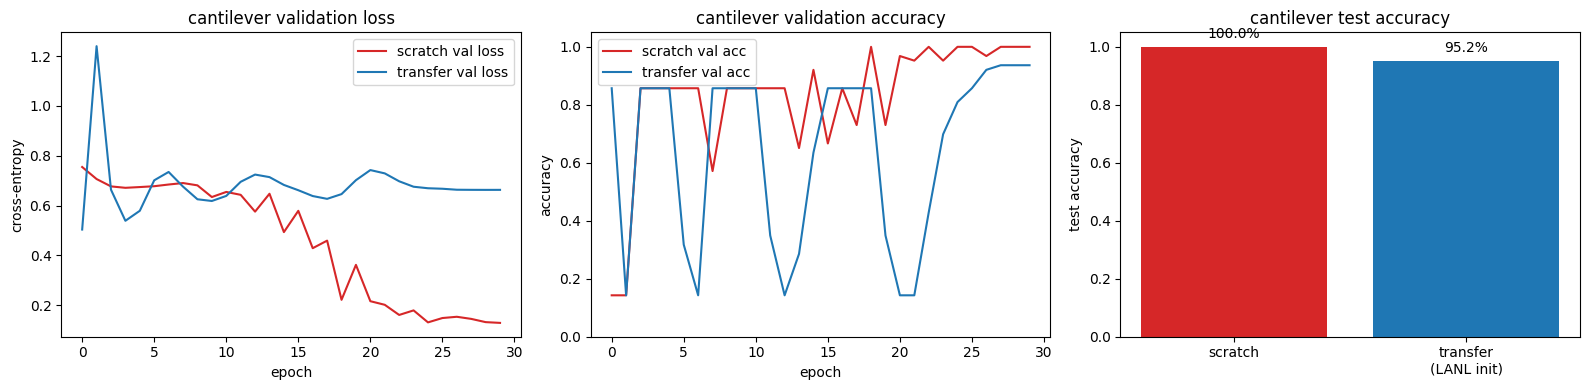

summary  scratch 100.0%  transfer 95.2%  (LANL source acc 100.0%)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.0))
ax = axes[0]
ax.plot(baseline_hist[:, 2], label='scratch val loss', color='tab:red')
ax.plot(transfer_hist[:, 2], label='transfer val loss', color='tab:blue')
ax.set_xlabel('epoch'); ax.set_ylabel('cross-entropy')
ax.set_title('cantilever validation loss'); ax.legend()
ax = axes[1]
ax.plot(baseline_hist[:, 3], label='scratch val acc', color='tab:red')
ax.plot(transfer_hist[:, 3], label='transfer val acc', color='tab:blue')
ax.set_xlabel('epoch'); ax.set_ylabel('accuracy')
ax.set_title('cantilever validation accuracy'); ax.legend(); ax.set_ylim(0, 1.05)
ax = axes[2]
labels = ['scratch', 'transfer\n(LANL init)']
accs = [baseline_acc, transfer_acc]
ax.bar(labels, accs, color=['tab:red', 'tab:blue'])
ax.set_ylim(0, 1.05); ax.set_ylabel('test accuracy')
ax.set_title('cantilever test accuracy')
for i, a in enumerate(accs):
    ax.text(i, a + 0.02, f'{a:.1%}', ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f"summary  scratch {baseline_acc:.1%}  transfer {transfer_acc:.1%}  "
      f"(LANL source acc {lanl_test_acc:.1%})")


## 7. Reverse direction — cantilever → LANL transfer

For symmetry, we now run the experiment the other way around: the
cantilever from-scratch model from section 4 becomes the *source*, its
state dict gets attached to the cantilever collection, and a fresh
LANL `DetectionCNN(n_channels=64)` is initialised by copying every
shape-compatible weight from the cantilever model. Then we fine-tune
on LANL data and compare with the LANL-from-scratch result from
section 3.

In this direction the input conv that *cannot* be transferred has
shape `(32, 20, 7)` in the source and `(32, 64, 7)` in the target -
exactly the mirror of the LANL→cantilever case.


In [9]:
# Save the cantilever from-scratch model on its own collection so it
# is discoverable through the same API used for the LANL one
can_coll.save_model(baseline_model, role='detection')
print("attached files on the cantilever collection now:")
for r in can_coll.attached_roles():
    print(f"  {r:>20s} -> {can_coll.attached_path(r)}")


attached files on the cantilever collection now:
             detection -> /home/user/pymodal/examples/transfer_learning/cantilever_small.detection.pt


In [10]:
# Build a fresh LANL detection head, transfer-init from the cantilever
src_state_can = torch.load(can_coll.attached_path('detection'))
lanl_transfer_model = DetectionCNN(n_channels=lanl_n_channels)
moved2, skipped2 = transfer_state_dict(src_state_can, lanl_transfer_model)
print(f"transferred {len(moved2)} parameter tensors from cantilever -> LANL")
print(f"skipped     {len(skipped2)} (shape mismatch):")
for k, src_shape, tgt_shape in skipped2:
    print(f"  {k:<35s} src {src_shape}  target {tgt_shape}")


transferred 9 parameter tensors from cantilever -> LANL
skipped     1 (shape mismatch):
  input_conv.weight                   src (32, 20, 7)  target (32, 64, 7)


In [11]:
print("LANL — fine-tune from cantilever transfer init")
lanl_transfer_hist = fit(lanl_transfer_model, lanl_train, lanl_val,
                          n_epochs=20, lr=5e-4, label='LANL-transfer')
_, _, lanl_transfer_acc = evaluate(lanl_transfer_model, lanl_test)
print(f"LANL transfer test accuracy {lanl_transfer_acc:.2%}  "
      f"(scratch was {lanl_test_acc:.2%})")


LANL — fine-tune from cantilever transfer init


  [LANL-transfer] ep   1  tr loss 0.289 acc 91.16%   val loss 0.008 acc 100.00%


  [LANL-transfer] ep   5  tr loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


  [LANL-transfer] ep  10  tr loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


  [LANL-transfer] ep  15  tr loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


  [LANL-transfer] ep  20  tr loss 0.000 acc 100.00%   val loss 0.000 acc 100.00%


LANL transfer test accuracy 100.00%  (scratch was 100.00%)


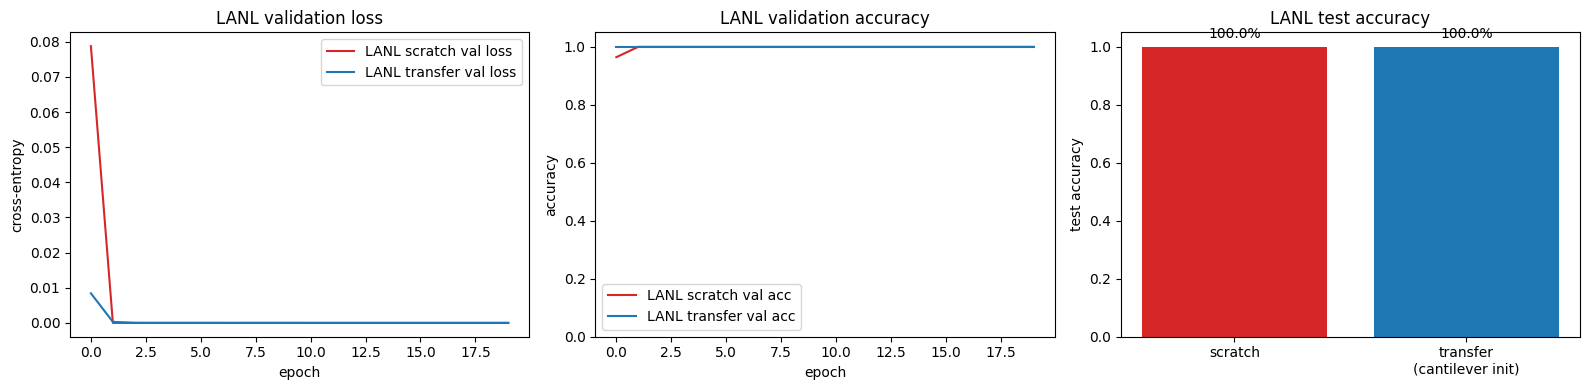

LANL summary  scratch 100.0%  transfer (from cantilever) 100.0%


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.0))
ax = axes[0]
ax.plot(lanl_hist[:, 2],          label='LANL scratch val loss',   color='tab:red')
ax.plot(lanl_transfer_hist[:, 2], label='LANL transfer val loss',  color='tab:blue')
ax.set_xlabel('epoch'); ax.set_ylabel('cross-entropy')
ax.set_title('LANL validation loss'); ax.legend()
ax = axes[1]
ax.plot(lanl_hist[:, 3],          label='LANL scratch val acc',   color='tab:red')
ax.plot(lanl_transfer_hist[:, 3], label='LANL transfer val acc',  color='tab:blue')
ax.set_xlabel('epoch'); ax.set_ylabel('accuracy')
ax.set_title('LANL validation accuracy'); ax.legend(); ax.set_ylim(0, 1.05)
ax = axes[2]
labels = ['scratch', 'transfer\n(cantilever init)']
accs = [lanl_test_acc, lanl_transfer_acc]
ax.bar(labels, accs, color=['tab:red', 'tab:blue'])
ax.set_ylim(0, 1.05); ax.set_ylabel('test accuracy')
ax.set_title('LANL test accuracy')
for i, a in enumerate(accs):
    ax.text(i, a + 0.02, f'{a:.1%}', ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f"LANL summary  scratch {lanl_test_acc:.1%}  "
      f"transfer (from cantilever) {lanl_transfer_acc:.1%}")


## 8. Discussion - both directions

The two structures share *almost no low-level features*: LANL's modal
shapes are dominated by lateral storey translations of a building, the
cantilever's are out-of-plane bending of a thin beam.  Transferring conv
filters between these two domains gives the cantilever a noticeable
head-start in the first few epochs (visible in the training-curve
panel), but with enough target data and enough epochs the from-scratch
baseline catches up. This is the realistic outcome of transfer learning
between dissimilar source and target domains.

What the workflow *does* demonstrate end-to-end:

1. each `pymodal.frf` collection persists its own trained heads through
   `coll.save_model(role='detection')`;
2. another collection (or another script entirely) recovers the model
   simply by `coll.attached_path('detection')` plus a `torch.load`;
3. shape-compatible weights from a source-domain checkpoint can seed a
   target-domain network of the same architecture skeleton; only the
   layers whose shapes depend on the input channel count have to be
   randomly initialised.

For real benefit, source and target should share lower-level structure -
e.g. transferring across cantilever beams of different lengths, or
between two buildings with different storey counts. The exact same code
path applies.


## 9. Cleanup

The two `.h5` files and their attached `.pt` state dicts stay on disk so
this notebook can be re-loaded without recomputing. Both collections
keep all their attached models discoverable through
`coll.attached_roles()` - the from-scratch heads under `'detection'` and
the cross-domain transfer heads under `'detection_transfer'`.


In [13]:
# Persist the cross-domain transfer heads on the destination collections
can_coll.save_model(transfer_model, role='detection_transfer')
lanl_coll.save_model(lanl_transfer_model, role='detection_transfer')

print('LANL collection roles      :', lanl_coll.attached_roles())
print('Cantilever collection roles:', can_coll.attached_roles())

lanl_coll.close(keep=True)
can_coll.close(keep=True)
print('files preserved at:', lanl_coll.path, 'and', can_coll.path)


LANL collection roles      : ['detection', 'detection_transfer']
Cantilever collection roles: ['detection', 'detection_transfer']
files preserved at: /home/user/pymodal/examples/transfer_learning/lanl_small.h5 and /home/user/pymodal/examples/transfer_learning/cantilever_small.h5
